<a href="https://colab.research.google.com/github/NikolaiMiranda/customer-segmentation-retail/blob/main/customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install ucimlrepo

In [76]:
import pandas as pd
from datetime import timedelta
from ucimlrepo import fetch_ucirepo

Gather and clean the data:

In [58]:
# fetch dataset
online_retail = fetch_ucirepo(id=352)

# create a dataframe to hold the data
# reading through the documentation for ucimlrepo we find that our data is split into dataframe labeled "ids" and "features"
# we will joing those together to form one dataframe
# Check that both dataframes are the same length and then join them
print(len(online_retail.data.ids) == len(online_retail.data.features))
df = online_retail.data.ids.join(online_retail.data.features)

True


In [59]:
# View the data
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [60]:
# Check if we have null values
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [61]:
# We have missing cutomer IDs
# We remove these since we need the IDs to match customers to their purchases and segment them
df.dropna(subset=['CustomerID'], inplace=True)

# Check to make sure null values have been discarded
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [77]:
# The documentation states that if an order is cancelled the InvoiceNo will start with a 'c'
# We will remove all canceled orders from the data since we want to segment customers based on their purchases
df = df[~df['InvoiceNo'].astype(str).str.startswith('c')]
# Note: ~ inverts the boolean


Feature engineering:

In [78]:
# Create a revenue variable
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df.head() # Display the first few rows with the new 'Revenue' column

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [80]:
# Create a recency variable
# We will base this off of days since last purchase
# C
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
snapshot_date = df['InvoiceDate'].max() + timedelta(days=1) # Think of this as last day in the set + 1 (current day)


<bound method Timestamp.date of Timestamp('2011-12-10 12:50:00')>

In [ ]:
# Create new RFM dataframe
rfm_df = df_no_cancelled.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda date: (snapshot_date - date.max()).days), # Days since last purchase
    Frequency=('InvoiceNo', 'nunique'),                                    # Number of unique invoices
    Monetary=('Revenue', 'sum')                                            # Total revenue
)
rfm_df.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


(0.0, 10000.0)

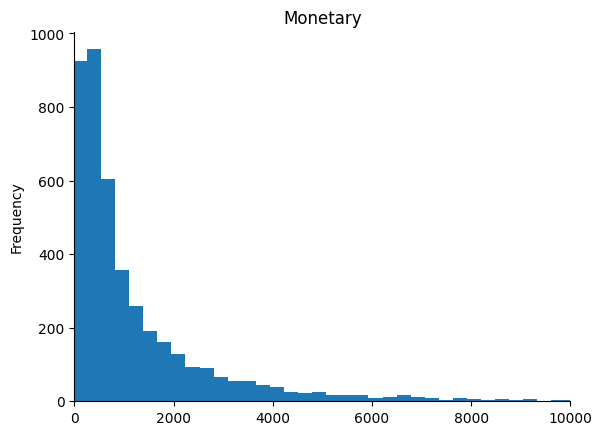

In [ ]:
# @title Monetary

from matplotlib import pyplot as plt
rfm_df['Monetary'].plot(kind='hist', bins=1000, title='Monetary')
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.xlim(0, 10000)

(0.0, 50.0)

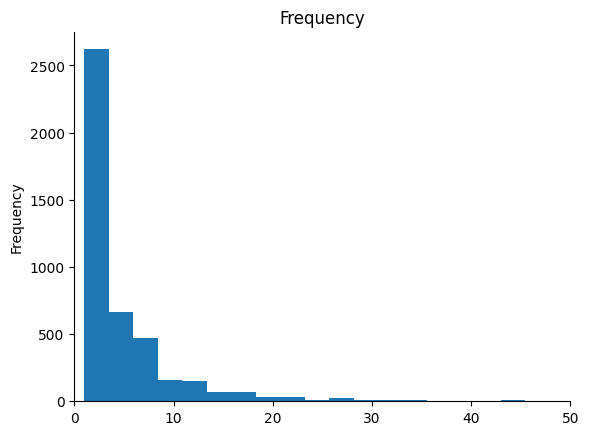

In [ ]:
# @title Frequency

from matplotlib import pyplot as plt
rfm_df['Frequency'].plot(kind='hist', bins=100, title='Frequency')
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.xlim(0, 50)

(0.0, 400.0)

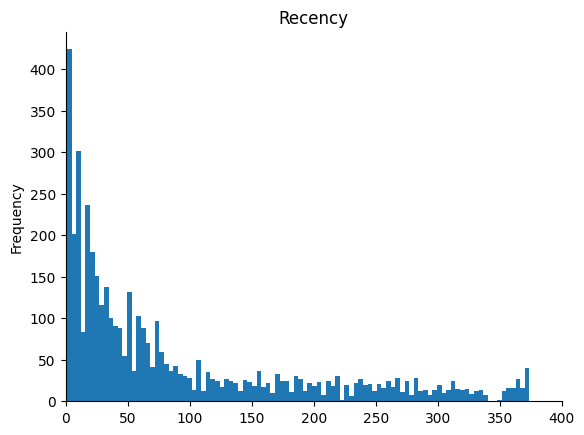

In [ ]:
# @title Recency

from matplotlib import pyplot as plt
rfm_df['Recency'].plot(kind='hist', bins=100, title='Recency')
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.xlim(0, 400)

In [ ]:
# Cell 16 (Revised again): Create RFM scores, letting qcut generate labels

# Frequency: Use qcut to create 4 quantiles. duplicates='drop' handles identical values.
# labels=False will make it assign integer codes from 0 to n-1 for the bins.
# We add 1 to make scores start from 1.
rfm_df['F_Score'] = pd.qcut(rfm_df['Frequency'], 4, labels=False, duplicates='drop') + 1

# Monetary: Same as Frequency
rfm_df['M_Score'] = pd.qcut(rfm_df['Monetary'], 4, labels=False, duplicates='drop') + 1

# Recency: For Recency, lower is better. We need to assign higher scores to lower Recency values.
# First, get the scores (higher value means higher Recency, which is bad)
# Then, subtract from 5 (if max score is 4) or (num_quantiles + 1) to reverse the scale.
rfm_df['R_Score'] = pd.qcut(rfm_df['Recency'], 4, labels=False, duplicates='drop') + 1
# Now, reverse the R_Score: if max score is 4, (5 - original_score)
rfm_df['R_Score'] = rfm_df['R_Score'].max() - rfm_df['R_Score'] + 1

rfm_df.head() # Display RFM DataFrame with new scores

,Recency,Frequency,Monetary,F_Score,M_Score,R_Score
CustomerID,,,,,,
12346.0,326,2,0.00,1,1,1
12347.0,2,7,4310.00,3,4,4
12348.0,75,4,1797.24,2,4,2
12349.0,19,1,1757.55,1,4,3
12350.0,310,1,334.40,1,2,1


In [ ]:
# Cell 17 (Same as before): Combine RFM scores into a single segment string
rfm_df['RFM_Segment'] = rfm_df['R_Score'].astype(str) + \
                        rfm_df['F_Score'].astype(str) + \
                        rfm_df['M_Score'].astype(str)
rfm_df.head() # Display RFM DataFrame with the new RFM_Segment

,Recency,Frequency,Monetary,F_Score,M_Score,R_Score,RFM_Segment
CustomerID,,,,,,,
12346.0,326,2,0.00,1,1,1,111
12347.0,2,7,4310.00,3,4,4,434
12348.0,75,4,1797.24,2,4,2,224
12349.0,19,1,1757.55,1,4,3,314
12350.0,310,1,334.40,1,2,1,112


In [ ]:
# Cell 18 (Same as before): Count customers in each RFM segment
rfm_df['RFM_Segment'].value_counts().sort_index()

,count
RFM_Segment,
111,519
112,339
113,103
114,21
121,8
122,21
123,27
124,12
131,4


In [ ]:
# Cell 19: Define RFM segments based on scores

def rfm_level(df):
    if df['R_Score'] == 4 and df['F_Score'] == 4 and df['M_Score'] == 4:
        return 'Champions' # Bought recently, buy often, and spend the most
    elif df['R_Score'] == 4 and df['F_Score'] == 4:
        return 'Loyal' # Bought recently, buy often
    elif df['R_Score'] == 4 and df['F_Score'] == 3:
        return 'Promising' # Bought recently, fair frequency
    elif df['R_Score'] == 4 and df['F_Score'] == 1:
        return 'New Customers' # Bought recently, but low frequency/monetary (just started)
    elif df['R_Score'] == 3 and df['F_Score'] == 4:
        return 'Potential Loyalists' # Spent good money, frequent, but not most recent
    elif df['R_Score'] == 3 and df['F_Score'] >=2 and df['M_Score'] >= 2:
        return 'Active' # Good recency, freq, and monetary
    elif df['R_Score'] == 2 and df['F_Score'] >= 2:
        return 'Waning' # Average recency, needs attention
    elif df['R_Score'] == 1 and df['M_Score'] >=2:
        return 'Big Spenders but At Risk' # High monetary but poor recency
    else:
        return 'Lost' # Low Recency, Frequency, and Monetary (e.g., '111', '121')

# Apply the function to create a new 'RFM_Level' column
rfm_df['RFM_Level'] = rfm_df.apply(rfm_level, axis=1)

rfm_df.head() # Display RFM DataFrame with the new RFM_Level

,Recency,Frequency,Monetary,F_Score,M_Score,R_Score,RFM_Segment,RFM_Level
CustomerID,,,,,,,,
12346.0,326,2,0.00,1,1,1,111,Lost
12347.0,2,7,4310.00,3,4,4,434,Promising
12348.0,75,4,1797.24,2,4,2,224,Waning
12349.0,19,1,1757.55,1,4,3,314,Lost
12350.0,310,1,334.40,1,2,1,112,Big Spenders but At Risk


In [ ]:
# Cell 21 (Revised): Calculate average RFM values for each segment
# First, reset the index to make CustomerID a regular column
rfm_df_reset = rfm_df.reset_index()

segment_averages = rfm_df_reset.groupby('RFM_Level').agg(
    AvgRecency=('Recency', 'mean'),
    AvgFrequency=('Frequency', 'mean'),
    AvgMonetary=('Monetary', 'mean'),
    CustomerCount=('CustomerID', 'count') # CustomerID is now a column
).sort_values(by='AvgMonetary', ascending=False)

segment_averages

,AvgRecency,AvgFrequency,AvgMonetary,CustomerCount
RFM_Level,,,,
Promising,7.039669,16.856198,7432.678231,605
Active,29.970356,7.928854,2835.781227,506
Waning,81.266055,6.134557,1848.491804,327
Big Spenders but At Risk,235.416517,2.427289,812.580451,557
New Customers,8.739938,2.030960,637.743932,323
Lost,108.316456,1.930867,538.137664,2054


/tmp/ipython-input-100-2483227168.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm_df, x='RFM_Level', order=rfm_df['RFM_Level'].value_counts().index, palette='viridis')


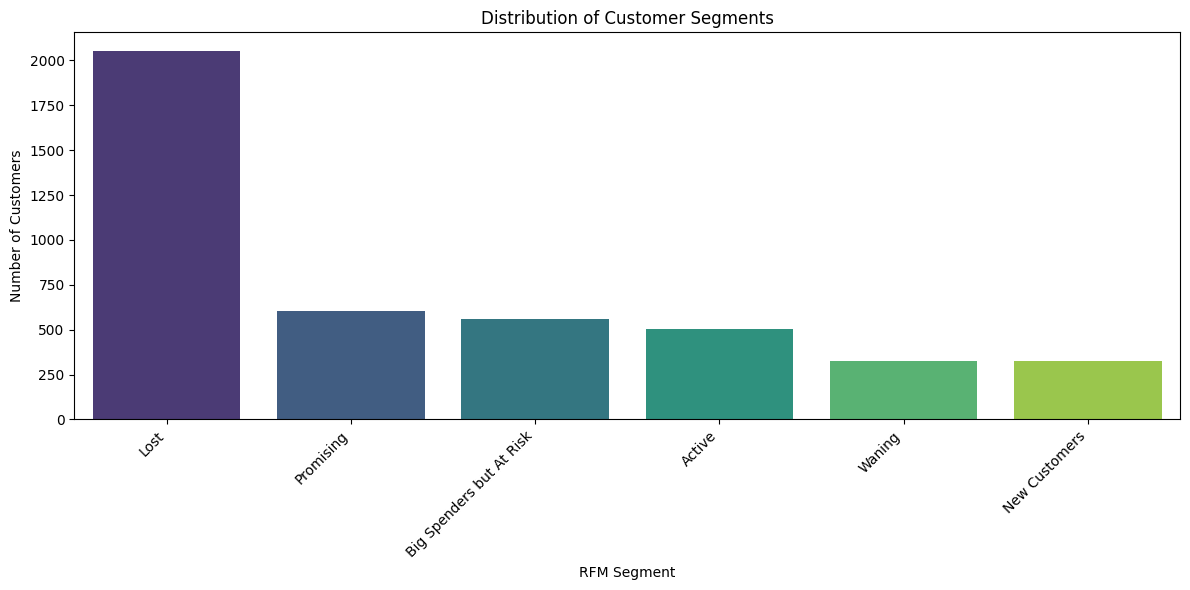

In [ ]:
# Cell 22: Visualize the distribution of customer segments
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6)) # Set a larger figure size for better readability
sns.countplot(data=rfm_df, x='RFM_Level', order=rfm_df['RFM_Level'].value_counts().index, palette='viridis')
plt.title('Distribution of Customer Segments')
plt.xlabel('RFM Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right') # Rotate labels for better fit
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

Now lets try with K-means

In [ ]:
# Cell 24: Feature Scaling for K-Means
from sklearn.preprocessing import StandardScaler

# Select the RFM features for clustering
rfm_features = rfm_df[['Recency', 'Frequency', 'Monetary']]

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the features
rfm_scaled = scaler.fit_transform(rfm_features)

# Convert the scaled array back to a DataFrame for easier handling
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=rfm_features.columns, index=rfm_df.index)

rfm_scaled_df.head() # Display the first few rows of the scaled data

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.322023,-0.329362,-0.231001
12347.0,-0.893733,0.206102,0.293432
12348.0,-0.169196,-0.115176,-0.012316
12349.0,-0.725005,-0.436455,-0.017146
12350.0,2.163220,-0.436455,-0.190312


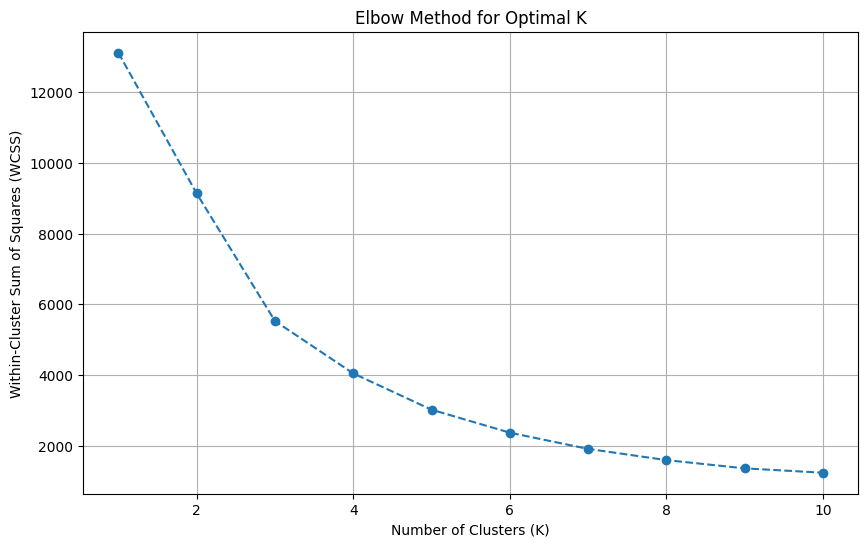

In [ ]:
# Cell 25: Determine optimal number of clusters using the Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

wcss = []
# Test different numbers of clusters from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(rfm_scaled_df)
    wcss.append(kmeans.inertia_) # inertia_ is the WCSS

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.show()

Choose K = 3

In [ ]:
# Cell 26: Apply K-Means Clustering with K=3
from sklearn.cluster import KMeans

# Initialize KMeans with the chosen K (3)
# n_init='auto' is the modern default for n_init
kmeans = KMeans(n_clusters=3, init='k-means++', n_init='auto', max_iter=300, random_state=42)

# Fit KMeans to the scaled RFM data and get cluster labels
rfm_df['Cluster_KMeans'] = kmeans.fit_predict(rfm_scaled_df)

rfm_df.head() # Display rfm_df with the new Cluster_KMeans column

,Recency,Frequency,Monetary,F_Score,M_Score,R_Score,RFM_Segment,RFM_Level,Cluster_KMeans
CustomerID,,,,,,,,,
12346.0,326,2,0.00,1,1,1,111,Lost,1
12347.0,2,7,4310.00,3,4,4,434,Promising,0
12348.0,75,4,1797.24,2,4,2,224,Waning,0
12349.0,19,1,1757.55,1,4,3,314,Lost,0
12350.0,310,1,334.40,1,2,1,112,Big Spenders but At Risk,1


In [ ]:
# Cell 27: Analyze K-Means Cluster Characteristics
# Use rfm_df (original, unscaled values) for meaningful averages
rfm_df = rfm_df.reset_index()
kmeans_cluster_analysis = rfm_df.groupby('Cluster_KMeans').agg(
    AvgRecency=('Recency', 'mean'),
    AvgFrequency=('Frequency', 'mean'),
    AvgMonetary=('Monetary', 'mean'),
    CustomerCount=('CustomerID', 'count') # Assuming CustomerID is now a regular column due to previous reset_index
).sort_values(by='AvgMonetary', ascending=False) # Sort by Monetary for easier comparison

kmeans_cluster_analysis

,AvgRecency,AvgFrequency,AvgMonetary,CustomerCount
Cluster_KMeans,,,,
2,6.086957,86.869565,81835.857391,23
0,40.091245,5.595561,1821.839757,3244
1,246.365611,1.846154,459.541105,1105


/tmp/ipython-input-105-3719124625.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm_df, x='Cluster_KMeans', palette='viridis')


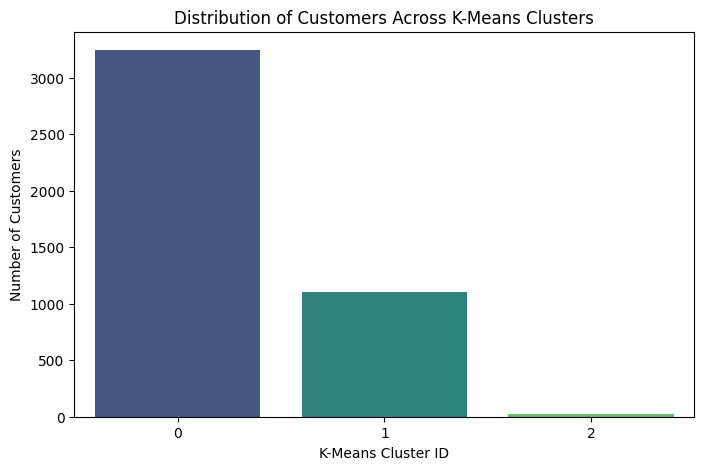

In [ ]:
# Cell 28: Visualize K-Means Cluster Sizes
plt.figure(figsize=(8, 5))
sns.countplot(data=rfm_df, x='Cluster_KMeans', palette='viridis')
plt.title('Distribution of Customers Across K-Means Clusters')
plt.xlabel('K-Means Cluster ID')
plt.ylabel('Number of Customers')
plt.show()

In [ ]:
# Cell 29: Map K-Means Cluster IDs to descriptive names

# IMPORTANT: VERIFY THESE MAPPINGS AGAINST YOUR ACTUAL kmeans_cluster_analysis OUTPUT (Cell 27)
# The cluster IDs (0, 1, 2) are arbitrary and can change with each run.
# Adjust the dictionary below based on the AvgRecency, AvgFrequency, and AvgMonetary for YOUR Cluster 0, 1, and 2.

# Example mapping (adjust based on your actual output):
# Based on my interpretation in the text above:
# Assuming Cluster 0 is At-Risk/Lapsed
# Assuming Cluster 1 is Champions/Loyal
# Assuming Cluster 2 is Potential/Developing
cluster_name_mapping = {
    0: 'At-Risk',
    1: 'Lost',
    2: 'Loyalists'
}

rfm_df['KMeans_Cluster_Name'] = rfm_df['Cluster_KMeans'].map(cluster_name_mapping)

rfm_df.head() # Display rfm_df with the new KMeans_Cluster_Name column

,CustomerID,Recency,Frequency,Monetary,F_Score,M_Score,R_Score,RFM_Segment,RFM_Level,Cluster_KMeans,KMeans_Cluster_Name
0,12346.0,326,2,0.00,1,1,1,111,Lost,1,Lost
1,12347.0,2,7,4310.00,3,4,4,434,Promising,0,At-Risk
2,12348.0,75,4,1797.24,2,4,2,224,Waning,0,At-Risk
3,12349.0,19,1,1757.55,1,4,3,314,Lost,0,At-Risk
4,12350.0,310,1,334.40,1,2,1,112,Big Spenders but At Risk,1,Lost


In [ ]:
# Cell 30: Count customers in each named K-Means cluster
rfm_df['KMeans_Cluster_Name'].value_counts()

,count
KMeans_Cluster_Name,
At-Risk,3244
Lost,1105
Loyalists,23
